## VALIDACIÓN DE WEIGHTED HIERARCHICAL CLUSTERING (W-Hierarchical)

### INICIALIZACIÓN: Weight Manager y clases de Clustering Jerárquico

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

import json
import tempfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

from src.clustering.traditional import HierarchicalClustering
from src.clustering.weighted import WeightedHierarchicalClustering
from src.weighting.weight_manager import WeightManager
from src.evaluation import calculate_metrics
from src.utils.constants import PROCESSED_DATA_PATH

sns.set_style('whitegrid')
np.random.seed(42)

# Helper: crea instancia de WeightManager temporal para pruebas
def make_temp_weight_manager(weights_dict: dict) -> WeightManager:
    tmp = tempfile.NamedTemporaryFile(suffix='.json', delete=False, mode='w', encoding='utf-8')
    json.dump({'features': weights_dict, 'metadata': {}}, tmp)
    tmp.close()
    return WeightManager(weight_path_=tmp.name)

print('='*70)
print('VALIDACIÓN W-HIERARCHICAL CLUSTERING')
print('='*70)

VALIDACIÓN W-HIERARCHICAL CLUSTERING


### ESCENARIOS DE PRUEBA

#### PRUEBA 1: VERIFICACIÓN DE INFLUENCIA DE PESOS EN CÁLCULO DE DISTANCIAS
Dataset de 2 features: `feature_1` contiene señal real, `feature_2` es ruido puro. Se asignan distintos pesos para verificar que la ponderación reorienta el agrupamiento hacia la señal relevante.

In [2]:
print('\n' + '='*70)
print('PRUEBA 1: VERIFICACIÓN DE APLICACIÓN DE PESOS')
print('='*70 + '\n')

# Generar dataset con señal controlada
X_p1, y_true_p1 = make_blobs(
    n_samples=200,
    centers=[[-1, 0], [1, 0]],  # más cercanos
    cluster_std=[1.2, 1.2],     # más dispersos
    random_state=42
)
# Agregar ruido dominante en feature_2
X_p1[:, 1] = np.random.normal(0, 6, size=200)

scaler_p1 = MinMaxScaler()
X_p1_scaled = scaler_p1.fit_transform(X_p1)
df_p1 = pd.DataFrame(X_p1_scaled, columns=['feature_1', 'feature_2'])

print(f'✓ Dataset generado: 200 muestras, 2 features')
print(f'  feature_1: señal real (2 clusters separados, std=0.5)')
print(f'  feature_2: poco relevante (std=6, varianza dominante)')

# Pesos: amplificar señal real, suprimir ruido
wm_p1 = make_temp_weight_manager({'feature_1': 1.0, 'feature_2': 0.2})
print(f'\n  Pesos asignados:')
print(f'    feature_1 = 1.00  (Dominante)')
print(f'    feature_2 = 0.20  (poco relevante)')

# Entrenar Hierarchical tradicional
hc_p1 = HierarchicalClustering(n_clusters=2, linkage='ward')
hc_p1.fit(df_p1)
metrics_hc_p1 = calculate_metrics(df_p1, hc_p1.labels_)

# Entrenar W-Hierarchical
whc_p1 = WeightedHierarchicalClustering(n_clusters=2, linkage='average', weight_manager=wm_p1)
whc_p1.fit(df_p1)
metrics_whc_p1 = calculate_metrics(df_p1, whc_p1.labels_)

print(f'\n✓ RESULTADOS:')
print(f"  {'Métrica':<28} {'Hierarchical':>14} {'W-Hierarchical':>14}")
print(f"  {'-'*58}")
print(f"  {'Silhouette':<28} {metrics_hc_p1['silhouette']:>14.4f} {metrics_whc_p1['silhouette']:>14.4f}")
print(f"  {'Davies-Bouldin':<28} {metrics_hc_p1['davies_bouldin']:>14.4f} {metrics_whc_p1['davies_bouldin']:>14.4f}")
print(f"  {'Calinski-Harabasz':<28} {metrics_hc_p1['calinski_harabasz']:>14.4f} {metrics_whc_p1['calinski_harabasz']:>14.4f}")


PRUEBA 1: VERIFICACIÓN DE APLICACIÓN DE PESOS

✓ Dataset generado: 200 muestras, 2 features
  feature_1: señal real (2 clusters separados, std=0.5)
  feature_2: poco relevante (std=6, varianza dominante)
Pesos cargados desde C:\Users\pabli\AppData\Local\Temp\tmppdj80f2x.json, total de características: 2.

  Pesos asignados:
    feature_1 = 1.00  (Dominante)
    feature_2 = 0.20  (poco relevante)
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 2 clusters
Calculando métricas de validación...
  Muestras: 200
  Clusters: 2
  ✓ Silhouette Score: 0.3333
  ✓ Davies-Bouldin Index: 1.1316
  ✓ Calinski-Harabasz Index: 114.4057
Entrenando Clustering Jerárquico Ponderado (average)...
✓ Clustering Jerárquico entrenado: 2 clusters
Calculando métricas de validación...
  Muestras: 200
  Clusters: 2
  ✓ Silhouette Score: 0.3366
  ✓ Davies-Bouldin Index: 0.4510
  ✓ Calinski-Harabasz Index: 3.9567

✓ RESULTADOS:
  Métrica                        Hierarchical W-Hierarchical
 

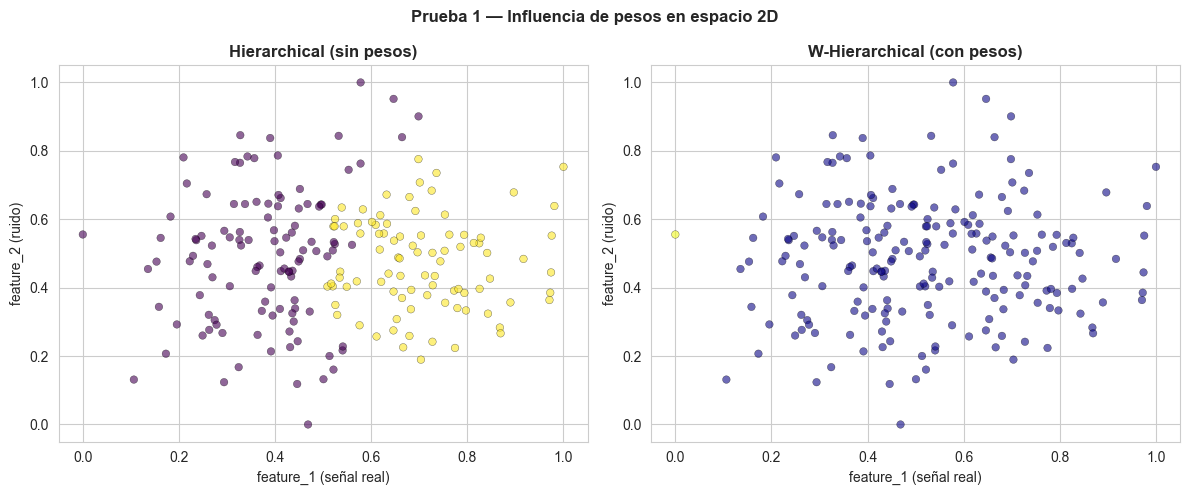

  W-Hierarchical debería agrupar según feature_1, ignorando el ruido de feature_2.


In [3]:
# Visualización Prueba 1
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Prueba 1 — Influencia de pesos en espacio 2D', fontweight='bold', fontsize=12)

axes[0].scatter(df_p1['feature_1'], df_p1['feature_2'], c=hc_p1.labels_,
                cmap='viridis', alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
axes[0].set_title('Hierarchical (sin pesos)', fontweight='bold')
axes[0].set_xlabel('feature_1 (señal real)')
axes[0].set_ylabel('feature_2 (ruido)')

axes[1].scatter(df_p1['feature_1'], df_p1['feature_2'], c=whc_p1.labels_,
                cmap='plasma', alpha=0.6, s=30, edgecolors='black', linewidth=0.3)
axes[1].set_title('W-Hierarchical (con pesos)', fontweight='bold')
axes[1].set_xlabel('feature_1 (señal real)')
axes[1].set_ylabel('feature_2 (ruido)')

plt.tight_layout()
plt.show()
print('  W-Hierarchical debería agrupar según feature_1, ignorando el ruido de feature_2.')

#### PRUEBA 2: COMPARATIVO SOBRE DATASET DE ALTA DIMENSIONALIDAD
Dataset de 600 muestras con 42 características: 9 con señal real y 33 de ruido puro. Se asignan pesos diferenciados para verificar que la ponderación suprime el ruido y mejora la separación.

In [4]:
print('\n' + '='*70)
print('PRUEBA 2: COMPARATIVO SOBRE ALTA DIMENSIONALIDAD')
print('='*70 + '\n')

N_RELEVANT = 9
N_NOISE = 33
N_TOTAL = N_RELEVANT + N_NOISE
N_SAMPLES = 600
N_CLUSTERS = 4

# Generar señal real
X_signal, y_true_p2 = make_blobs(
    n_samples=N_SAMPLES,
    n_features=N_RELEVANT,
    centers=N_CLUSTERS,
    cluster_std=3.5,
    random_state=42
)
# Agregar ruido de alta varianza
X_noise = np.random.normal(0, 8, size=(N_SAMPLES, N_NOISE))
X_p2 = np.hstack([X_signal, X_noise])

scaler_p2 = MinMaxScaler()
X_p2_scaled = scaler_p2.fit_transform(X_p2)

feature_names = [f'relevant_{i}' for i in range(N_RELEVANT)] + \
                [f'noise_{i}' for i in range(N_NOISE)]
df_p2 = pd.DataFrame(X_p2_scaled, columns=feature_names)

print(f'✓ Dataset generado: {N_SAMPLES} muestras, {N_TOTAL} features')
print(f'  {N_RELEVANT} features con señal real (std=1.0)')
print(f'  {N_NOISE} features de ruido (std=8)')

# Esquema de pesos: amplificar relevantes, suprimir ruido
weights_p2 = {f'relevant_{i}': 1.0 for i in range(N_RELEVANT)}
weights_p2.update({f'noise_{i}': 0.05 for i in range(N_NOISE)})
wm_p2 = make_temp_weight_manager(weights_p2)
print(f'  Pesos: relevantes=1.00, ruido=0.05')

# Entrenar Hierarchical tradicional
hc_p2 = HierarchicalClustering(n_clusters=N_CLUSTERS, linkage='ward')
hc_p2.fit(df_p2)
metrics_hc_p2 = calculate_metrics(df_p2, hc_p2.labels_)

# Entrenar W-Hierarchical
whc_p2 = WeightedHierarchicalClustering(n_clusters=N_CLUSTERS, linkage='average', weight_manager=wm_p2)
whc_p2.fit(df_p2)
metrics_whc_p2 = calculate_metrics(df_p2, whc_p2.labels_)

# Calcular deltas
delta_sil = (metrics_whc_p2['silhouette'] - metrics_hc_p2['silhouette']) / abs(metrics_hc_p2['silhouette']) * 100
delta_db  = (metrics_hc_p2['davies_bouldin'] - metrics_whc_p2['davies_bouldin']) / abs(metrics_hc_p2['davies_bouldin']) * 100
delta_ch  = (metrics_whc_p2['calinski_harabasz'] - metrics_hc_p2['calinski_harabasz']) / abs(metrics_hc_p2['calinski_harabasz']) * 100

print(f'\n✓ RESULTADOS:')
print(f"  {'Métrica':<28} {'Hierarchical':>14} {'W-Hierarchical':>14} {'Δ':>8}")
print(f"  {'-'*68}")
print(f"  {'Silhouette':<28} {metrics_hc_p2['silhouette']:>14.4f} {metrics_whc_p2['silhouette']:>14.4f} {delta_sil:>+7.1f}%")
print(f"  {'Davies-Bouldin':<28} {metrics_hc_p2['davies_bouldin']:>14.4f} {metrics_whc_p2['davies_bouldin']:>14.4f} {delta_db:>+7.1f}%")
print(f"  {'Calinski-Harabasz':<28} {metrics_hc_p2['calinski_harabasz']:>14.4f} {metrics_whc_p2['calinski_harabasz']:>14.4f} {delta_ch:>+7.1f}%")


PRUEBA 2: COMPARATIVO SOBRE ALTA DIMENSIONALIDAD

✓ Dataset generado: 600 muestras, 42 features
  9 features con señal real (std=1.0)
  33 features de ruido (std=8)
Pesos cargados desde C:\Users\pabli\AppData\Local\Temp\tmpgiezff50.json, total de características: 42.
  Pesos: relevantes=1.00, ruido=0.05
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 4 clusters
Calculando métricas de validación...
  Muestras: 600
  Clusters: 4
  ✓ Silhouette Score: 0.0764
  ✓ Davies-Bouldin Index: 3.1862
  ✓ Calinski-Harabasz Index: 37.5706
Entrenando Clustering Jerárquico Ponderado (average)...
✓ Clustering Jerárquico entrenado: 4 clusters
Calculando métricas de validación...
  Muestras: 600
  Clusters: 4
  ✓ Silhouette Score: 0.0874
  ✓ Davies-Bouldin Index: 2.9655
  ✓ Calinski-Harabasz Index: 41.6666

✓ RESULTADOS:
  Métrica                        Hierarchical W-Hierarchical        Δ
  --------------------------------------------------------------------
  Silhouette   

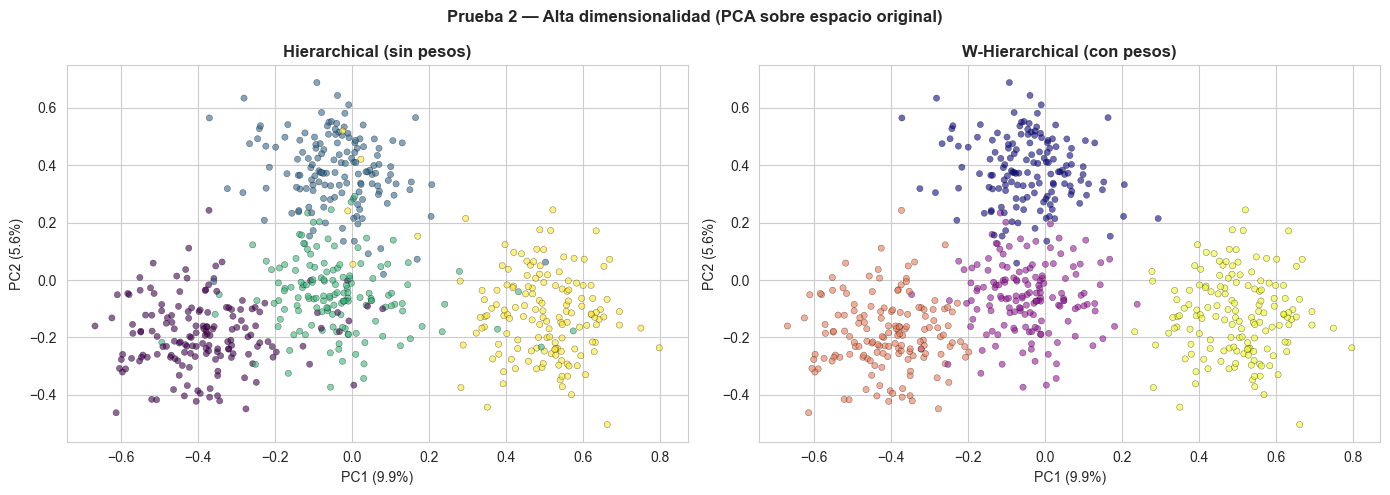

  Las características relevantes dominan la proyección en W-Hierarchical.


In [5]:
# Visualización Prueba 2 — PCA
pca_p2 = PCA(n_components=2, random_state=42)
X_2d_p2 = pca_p2.fit_transform(df_p2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prueba 2 — Alta dimensionalidad (PCA sobre espacio original)',
             fontweight='bold', fontsize=12)

axes[0].scatter(X_2d_p2[:, 0], X_2d_p2[:, 1], c=hc_p2.labels_,
                cmap='viridis', alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
axes[0].set_title('Hierarchical (sin pesos)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_p2.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_p2.explained_variance_ratio_[1]*100:.1f}%)')

axes[1].scatter(X_2d_p2[:, 0], X_2d_p2[:, 1], c=whc_p2.labels_,
                cmap='plasma', alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
axes[1].set_title('W-Hierarchical (con pesos)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_p2.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_p2.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.show()
print('  Las características relevantes dominan la proyección en W-Hierarchical.')

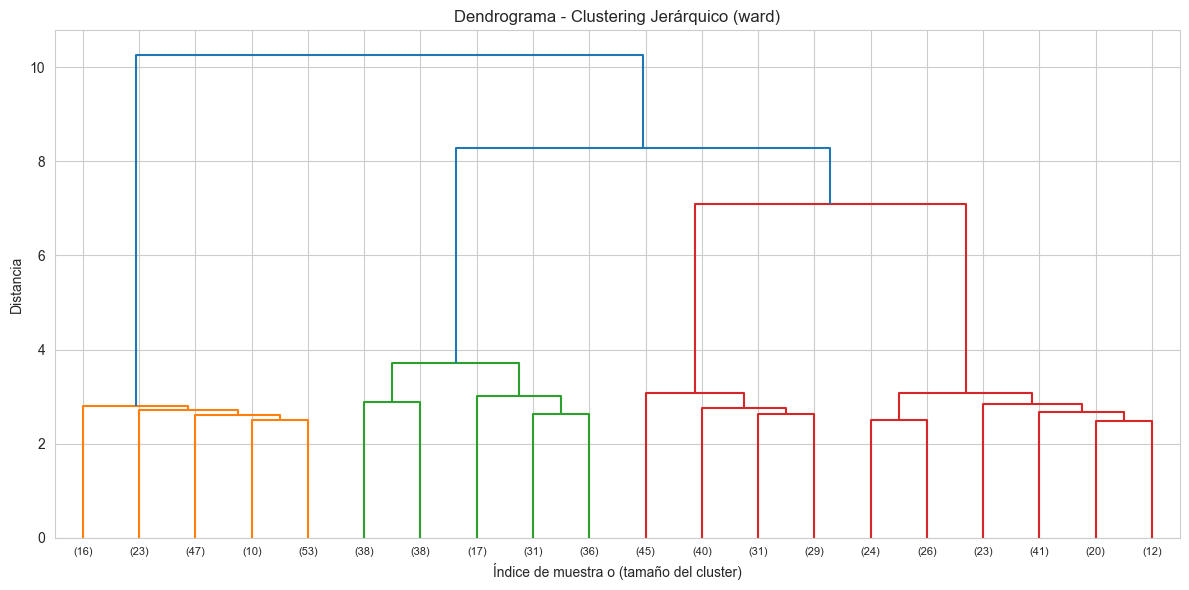

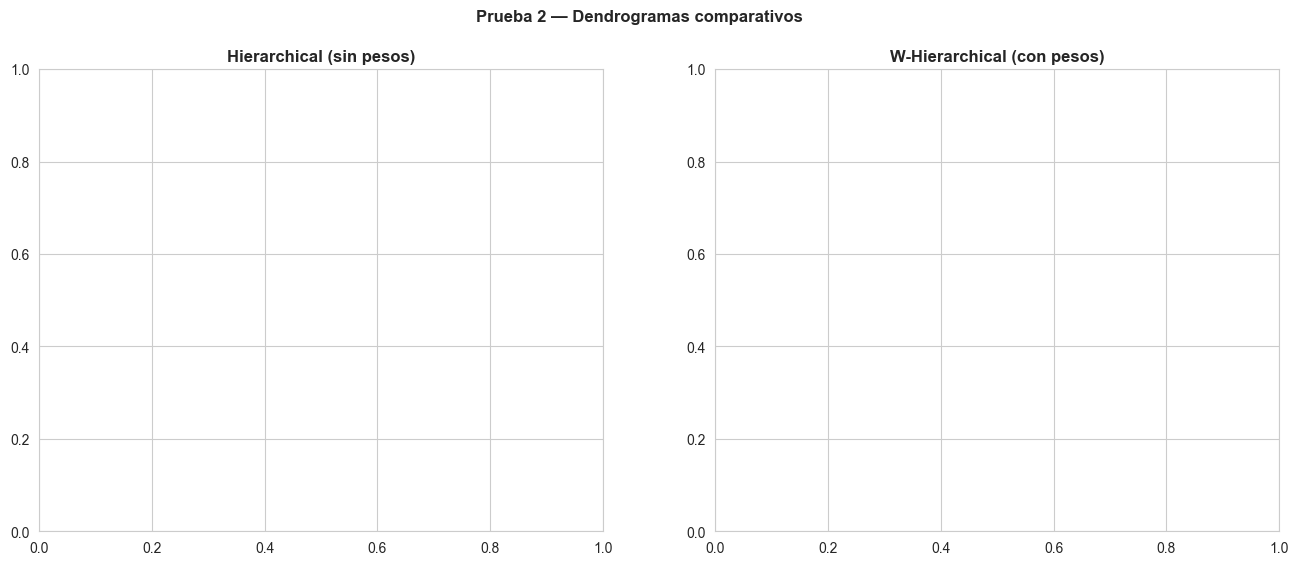

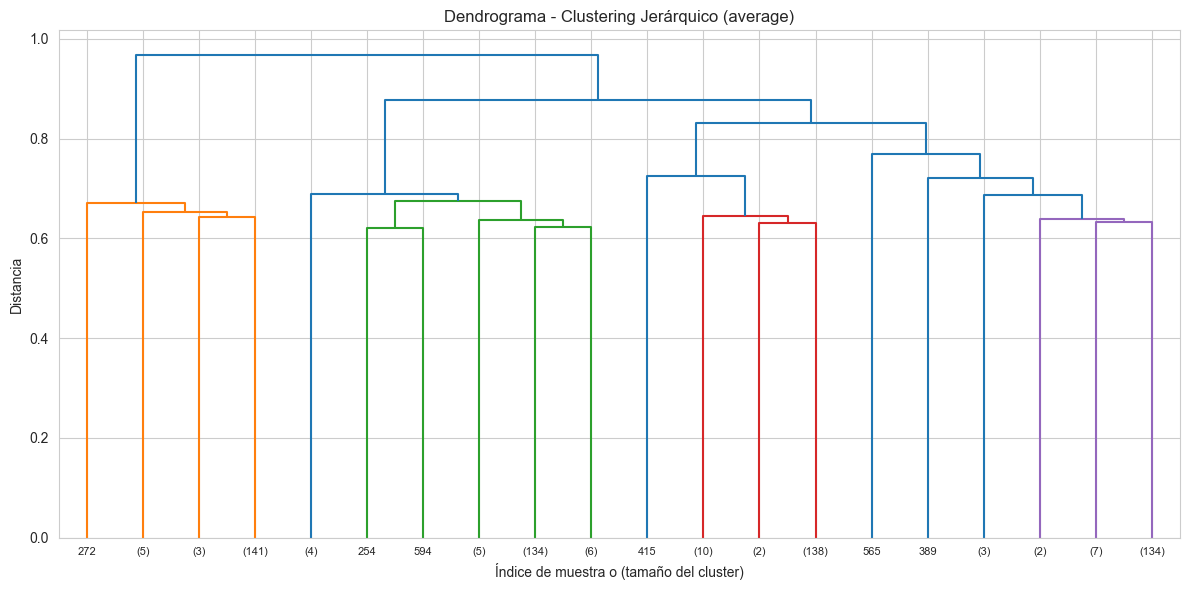

In [6]:
# Dendrogramas comparativos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Prueba 2 — Dendrogramas comparativos', fontweight='bold', fontsize=12)

plt.sca(axes[0])
hc_p2.plot_dendrogram(truncate_mode='lastp', p=20)
axes[0].set_title('Hierarchical (sin pesos)', fontweight='bold')

plt.sca(axes[1])
whc_p2.plot_dendrogram(truncate_mode='lastp', p=20)
axes[1].set_title('W-Hierarchical (con pesos)', fontweight='bold')

plt.tight_layout()
plt.show()

### RESUMEN DE VALIDACIÓN

#### PRUEBA 3: CARGA DEL ESQUEMA DE PONDERACIÓN REAL
W-Hierarchical operando con la ponderación real del proyecto. Se genera un dataset sintético con las 42 columnas del esquema electoral para verificar compatibilidad operativa del módulo de ponderación.

In [6]:
print('\n' + '='*70)
print('PRUEBA 3: CARGA DEL ESQUEMA DE PONDERACIÓN REAL')
print('='*70)

wm_real = WeightManager()
weights_dict = wm_real.get_weights()
feature_names_real = list(weights_dict.keys())
n_features_real = len(feature_names_real)

print(f'\n✓ WeightManager cargado: {n_features_real} características')
print(f'  Ruta: {wm_real.weights_path_}')
print(f'  Rango de pesos: [{min(weights_dict.values()):.2f}, {max(weights_dict.values()):.2f}]')

# Dataset sintético con las columnas del esquema real
np.random.seed(42)
X_p3_raw, _ = make_blobs(
    n_samples=500,
    n_features=n_features_real,
    centers=3,
    cluster_std=2.0,
    random_state=42
)
df_p3_real = pd.DataFrame(
    MinMaxScaler().fit_transform(X_p3_raw),
    columns=feature_names_real
)
print(f'\n✓ Dataset sintético: {df_p3_real.shape[0]} muestras, {df_p3_real.shape[1]} features')
print(f'  (Columnas = features del esquema electoral real)')

# Entrenar solo W-Hierarchical con esquema real
whc_p3 = WeightedHierarchicalClustering(n_clusters=3, linkage='average', weight_manager=wm_real)
whc_p3.fit(df_p3_real)
metrics_whc_p3 = calculate_metrics(df_p3_real, whc_p3.labels_)

weights_arr_p3 = wm_real.get_weights_array(feature_order=df_p3_real.columns.tolist())
print(f'\n✓ Verificación de pesos:')
print(f'  Array extraído: {len(weights_arr_p3)} valores')
print(f'  Primeros 5 pesos: {[round(w, 2) for w in weights_arr_p3[:5]]}')
print(f'  Corresponden a features: {feature_names[:5]}')

print(f'\n✓ RESULTADOS:')
print(f'  W-Hierarchical: {whc_p3.n_clusters_} clusters identificados')
print(f'  Silhouette:        {metrics_whc_p3["silhouette"]:.4f}')
print(f'  Davies-Bouldin:    {metrics_whc_p3["davies_bouldin"]:.4f}')
print(f'  Calinski-Harabasz: {metrics_whc_p3["calinski_harabasz"]:.4f}')
print('\n' + '='*70)


PRUEBA 3: CARGA DEL ESQUEMA DE PONDERACIÓN REAL
Pesos cargados desde c:\electocluster\src\weighting\schemas\feature_weights.json, total de características: 42.

✓ WeightManager cargado: 42 características
  Ruta: c:\electocluster\src\weighting\schemas\feature_weights.json
  Rango de pesos: [0.50, 1.00]

✓ Dataset sintético: 500 muestras, 42 features
  (Columnas = features del esquema electoral real)
Entrenando Clustering Jerárquico Ponderado (average)...
✓ Clustering Jerárquico entrenado: 3 clusters
Calculando métricas de validación...
  Muestras: 500
  Clusters: 3
  ✓ Silhouette Score: 0.5673
  ✓ Davies-Bouldin Index: 0.6713
  ✓ Calinski-Harabasz Index: 751.3456

✓ Verificación de pesos:
  Array extraído: 42 valores
  Primeros 5 pesos: [1.0, 1.0, 0.75, 0.7, 0.7]
  Corresponden a features: ['relevant_0', 'relevant_1', 'relevant_2', 'relevant_3', 'relevant_4']

✓ RESULTADOS:
  W-Hierarchical: 3 clusters identificados
  Silhouette:        0.5673
  Davies-Bouldin:    0.6713
  Calinski-Ha

#### PRUEBA 4: COMPARATIVO SOBRE DATASET ELECTORAL REAL
Ejecuta HierarchicalClustering y WeightedHierarchicalClustering sobre el dataset electoral preprocesado. Incluye métricas de validación, distribución de clusters y visualización PCA.


PRUEBA 4: COMPARATIVO SOBRE DATASET ELECTORAL REAL

✓ Dataset cargado: 1706 registros × 28 variables
  Missings: 0
Pesos cargados desde c:\electocluster\src\weighting\schemas\feature_weights.json, total de características: 42.
Entrenando Clustering Jerárquico (ward)...
✓ Clustering Jerárquico entrenado: 3 clusters
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 3
  ✓ Silhouette Score: 0.0952
  ✓ Davies-Bouldin Index: 2.9659
  ✓ Calinski-Harabasz Index: 187.1927
Entrenando Clustering Jerárquico Ponderado (average)...
✓ Clustering Jerárquico entrenado: 3 clusters
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 3
  ✓ Silhouette Score: 0.1063
  ✓ Davies-Bouldin Index: 1.3710
  ✓ Calinski-Harabasz Index: 3.5280

✓ MÉTRICAS DE VALIDACIÓN:
  Algoritmo                        Silhouette   Davies-Bouldin     Calinski-H
  --------------------------------------------------------------------------
  Hierarchical (sin pesos)             0.0952           2.9659   

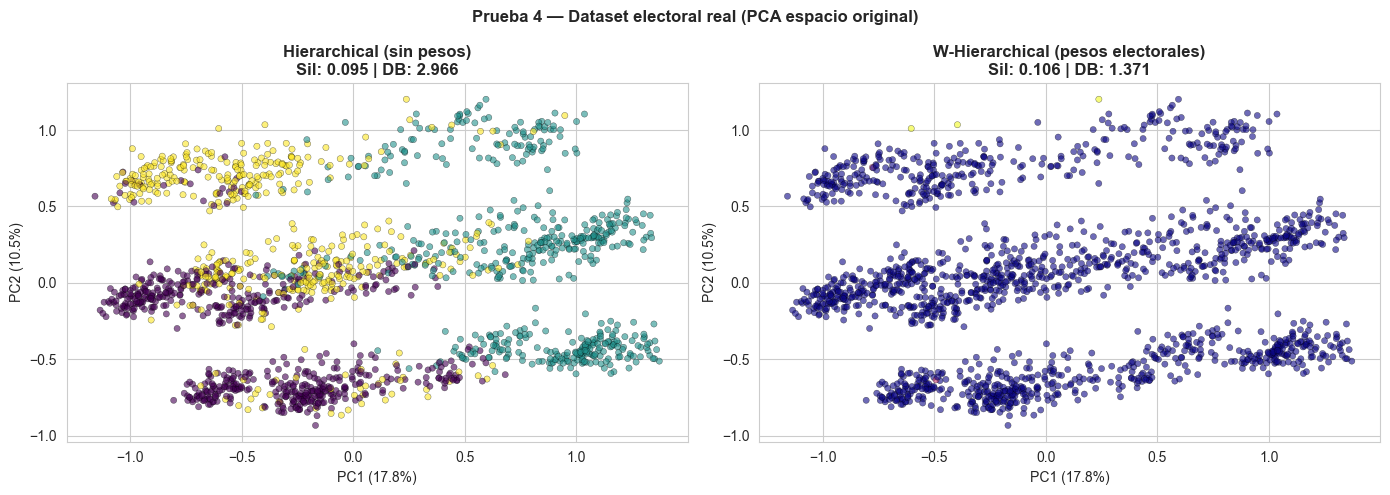

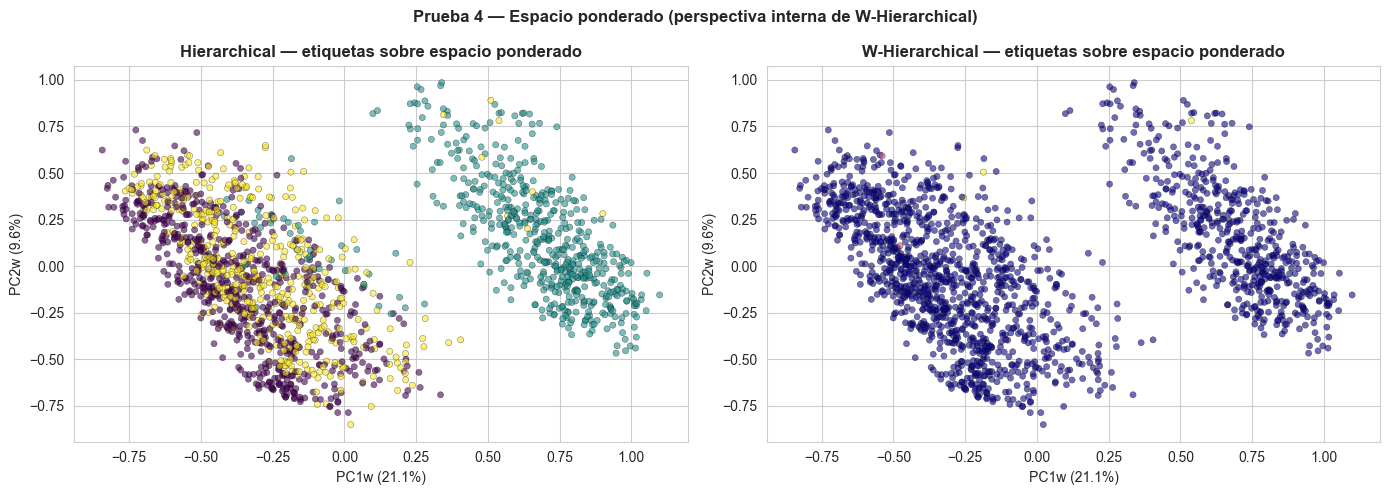

  Las características con mayor peso electoral dominan la proyección PCA.


In [7]:
print('\n' + '='*70)
print('PRUEBA 4: COMPARATIVO SOBRE DATASET ELECTORAL REAL')
print('='*70 + '\n')

# Cargar dataset electoral
df_electoral = pd.read_csv(PROCESSED_DATA_PATH)
print(f'✓ Dataset cargado: {df_electoral.shape[0]} registros × {df_electoral.shape[1]} variables')
print(f'  Missings: {df_electoral.isnull().sum().sum()}')

wm_electoral = WeightManager()
N_CLUSTERS_P4 = 3

# Hierarchical tradicional
hc_p4 = HierarchicalClustering(n_clusters=N_CLUSTERS_P4, linkage='ward')
hc_p4.fit(df_electoral)
metrics_hc_p4 = calculate_metrics(df_electoral, hc_p4.labels_)

# W-Hierarchical con pesos electorales
whc_p4 = WeightedHierarchicalClustering(n_clusters=N_CLUSTERS_P4, linkage='average', weight_manager=wm_electoral)
whc_p4.fit(df_electoral)
metrics_whc_p4 = calculate_metrics(df_electoral, whc_p4.labels_)

print(f'\n✓ MÉTRICAS DE VALIDACIÓN:')
print(f"  {'Algoritmo':<30} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-H':>14}")
print(f"  {'-'*74}")
print(f"  {'Hierarchical (sin pesos)':<30} {metrics_hc_p4['silhouette']:>12.4f} {metrics_hc_p4['davies_bouldin']:>16.4f} {metrics_hc_p4['calinski_harabasz']:>14.4f}")
print(f"  {'W-Hierarchical (con pesos)':<30} {metrics_whc_p4['silhouette']:>12.4f} {metrics_whc_p4['davies_bouldin']:>16.4f} {metrics_whc_p4['calinski_harabasz']:>14.4f}")

# Distribución de clusters
dist_hc  = pd.Series(hc_p4.labels_).value_counts().sort_index()
dist_whc = pd.Series(whc_p4.labels_).value_counts().sort_index()

print(f'\n✓ DISTRIBUCIÓN DE CLUSTERS:')
print(f"  {'Cluster':<10} {'Hierarchical':>14} {'W-Hierarchical':>16}")
print(f"  {'-'*42}")
for c in sorted(set(list(dist_hc.index) + list(dist_whc.index))):
    hc_n  = dist_hc.get(c, 0)
    whc_n = dist_whc.get(c, 0)
    print(f"  {c:<10} {hc_n:>14} {whc_n:>16}")

# Visualización PCA espacio original
pca_p4 = PCA(n_components=2, random_state=42)
X_2d_p4 = pca_p4.fit_transform(df_electoral)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prueba 4 — Dataset electoral real (PCA espacio original)', fontweight='bold', fontsize=12)

axes[0].scatter(X_2d_p4[:, 0], X_2d_p4[:, 1], c=hc_p4.labels_, cmap='viridis',
                alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
axes[0].set_title(f'Hierarchical (sin pesos)\nSil: {metrics_hc_p4["silhouette"]:.3f} | DB: {metrics_hc_p4["davies_bouldin"]:.3f}', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_p4.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_p4.explained_variance_ratio_[1]*100:.1f}%)')

axes[1].scatter(X_2d_p4[:, 0], X_2d_p4[:, 1], c=whc_p4.labels_, cmap='plasma',
                alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
axes[1].set_title(f'W-Hierarchical (pesos electorales)\nSil: {metrics_whc_p4["silhouette"]:.3f} | DB: {metrics_whc_p4["davies_bouldin"]:.3f}', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_p4.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_p4.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.show()

# Visualización PCA espacio ponderado
weights_electoral_arr = wm_electoral.get_weights_array(feature_order=df_electoral.columns.tolist())
df_electoral_weighted = df_electoral * weights_electoral_arr

pca_p4w = PCA(n_components=2, random_state=42)
X_2d_p4w = pca_p4w.fit_transform(df_electoral_weighted)

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Prueba 4 — Espacio ponderado (perspectiva interna de W-Hierarchical)', fontweight='bold', fontsize=12)

axes2[0].scatter(X_2d_p4w[:, 0], X_2d_p4w[:, 1], c=hc_p4.labels_, cmap='viridis',
                 alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
axes2[0].set_title('Hierarchical — etiquetas sobre espacio ponderado', fontweight='bold')
axes2[0].set_xlabel(f'PC1w ({pca_p4w.explained_variance_ratio_[0]*100:.1f}%)')
axes2[0].set_ylabel(f'PC2w ({pca_p4w.explained_variance_ratio_[1]*100:.1f}%)')

axes2[1].scatter(X_2d_p4w[:, 0], X_2d_p4w[:, 1], c=whc_p4.labels_, cmap='plasma',
                 alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
axes2[1].set_title('W-Hierarchical — etiquetas sobre espacio ponderado', fontweight='bold')
axes2[1].set_xlabel(f'PC1w ({pca_p4w.explained_variance_ratio_[0]*100:.1f}%)')
axes2[1].set_ylabel(f'PC2w ({pca_p4w.explained_variance_ratio_[1]*100:.1f}%)')

plt.tight_layout()
plt.show()
print('  Las características con mayor peso electoral dominan la proyección PCA.')

In [8]:
print('\n' + '='*70)
print('RESUMEN DE VALIDACIÓN W-HIERARCHICAL CLUSTERING')
print('='*70)

resultados = [
    {
        'Prueba': '1. Verificación de aplicación de pesos',
        'HC_Sil': metrics_hc_p1['silhouette'],
        'WHC_Sil': metrics_whc_p1['silhouette'],
        'Resultado': 'PASS' if whc_p1.n_clusters_ == 2 else 'REVISAR'
    },
    {
        'Prueba': '2. Dataset generado de alta dimensionalidad',
        'HC_Sil': metrics_hc_p2['silhouette'],
        'WHC_Sil': metrics_whc_p2['silhouette'],
        'Resultado': 'PASS' if whc_p2.n_clusters_ == N_CLUSTERS else 'REVISAR'
    },
    {
        'Prueba': '3. Carga esquema ponderación real (42 características)',
        'HC_Sil': None,
        'WHC_Sil': metrics_whc_p3['silhouette'],
        'Resultado': 'PASS' if whc_p3.n_clusters_ == 3 else 'REVISAR'
    },
    {
        'Prueba': '4. Comparativo sobre dataset electoral real',
        'HC_Sil': metrics_hc_p4['silhouette'],
        'WHC_Sil': metrics_whc_p4['silhouette'],
        'Resultado': 'PASS' if whc_p4.n_clusters_ == N_CLUSTERS_P4 else 'REVISAR'
    }
]

print(f"\n  {'Prueba':<46} {'HC':>10} {'W-HC':>10} {'Estado':>8}")
print(f"  {'-'*76}")
for r in resultados:
    hc_str = f"{r['HC_Sil']:.4f}" if r['HC_Sil'] is not None else '   N/A'
    print(f"  {r['Prueba']:<46} {hc_str:>10} {r['WHC_Sil']:>10.4f} {r['Resultado']:>8}")

todos_pass = all(r['Resultado'] == 'PASS' for r in resultados)
print(f"\n  {'✓ TODAS LAS PRUEBAS PASARON' if todos_pass else '⚠ REVISAR PRUEBAS MARCADAS'}")
print('\n' + '='*70)



RESUMEN DE VALIDACIÓN W-HIERARCHICAL CLUSTERING

  Prueba                                                 HC       W-HC   Estado
  ----------------------------------------------------------------------------
  1. Verificación de aplicación de pesos             0.3333     0.3366     PASS
  2. Dataset generado de alta dimensionalidad        0.0764     0.0874     PASS
  3. Carga esquema ponderación real (42 características)        N/A     0.5673     PASS
  4. Comparativo sobre dataset electoral real        0.0952     0.1063     PASS

  ✓ TODAS LAS PRUEBAS PASARON

